<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI006-24BAD056-DL/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 24BAD056 - M.Karthik Saravanakumar


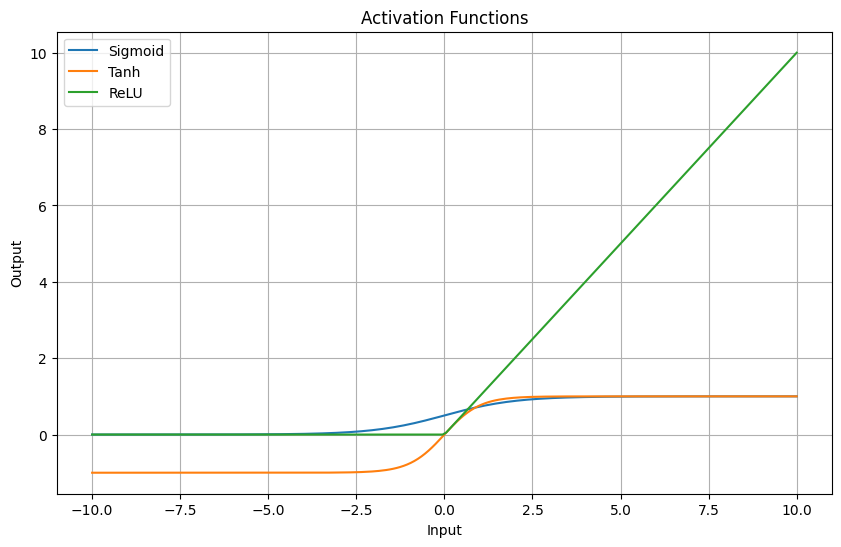

In [1]:
print(" 24BAD056 - M.Karthik Saravanakumar")

#PART-A
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# Input values
x = np.linspace(-10, 10, 200)
# Activation Functions
sigmoid = tf.keras.activations.sigmoid(x)
tanh = tf.keras.activations.tanh(x)
relu = tf.keras.activations.relu(x)
# Plot
plt.figure(figsize=(10,6))
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.plot(x, relu, label='ReLU')

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()

In [2]:
# 24BAD056-M.Karthik Saravanakumar
#PART-B

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
# Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0
# Function to create ANN
def create_model(activation):
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
activations = ['sigmoid', 'tanh', 'relu']
histories = {}
for act in activations:
    print(f"\nTraining using {act}")
    model = create_model(act)
    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        validation_split=0.2,
        verbose=1
    )
    histories[act] = history
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy ({act}) = {acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training using sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8657 - loss: 0.5311 - val_accuracy: 0.9317 - val_loss: 0.2428
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9399 - loss: 0.2060 - val_accuracy: 0.9492 - val_loss: 0.1778
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9565 - loss: 0.1456 - val_accuracy: 0.9594 - val_loss: 0.1367
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9682 - loss: 0.1088 - val_accuracy: 0.9657 - val_loss: 0.1223
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9755 - loss: 0.0846 - val_accuracy: 0.9680 - val_loss: 0.1059
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9797 - loss: 0.0672 - val_accuracy: 0.9711 - val_loss: 0.0998
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9843 - loss: 0.0541 - val_accuracy: 0.9705 - val_loss: 0.0937
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9883 - loss: 0.0430 -

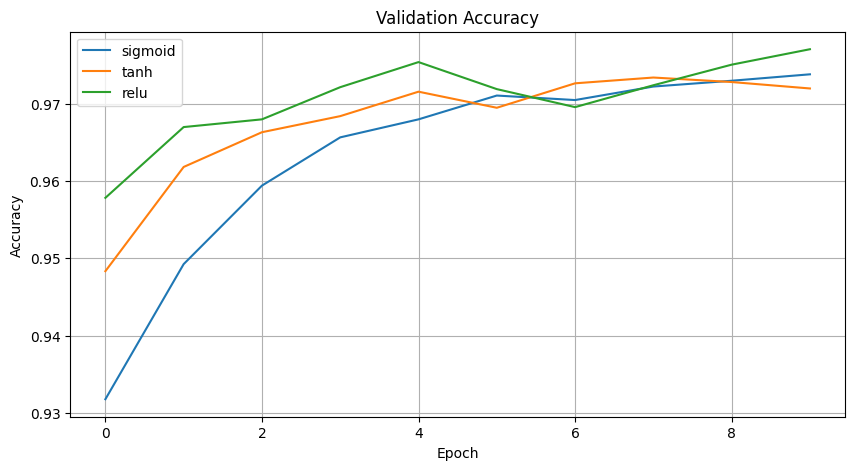

In [3]:
plt.figure(figsize=(10,5))
for act in activations:
    plt.plot(histories[act].history['val_accuracy'], label=act)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

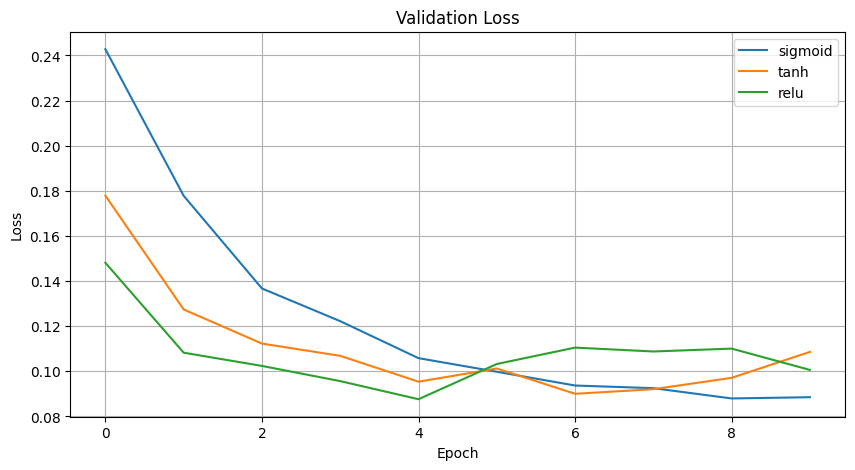

In [4]:
plt.figure(figsize=(10,5))
for act in activations:
    plt.plot(histories[act].history['val_loss'], label=act)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# 24BAD056-M.Karthik Saravanakumar
#PART-C

from tensorflow.keras.optimizers import SGD, RMSprop, Adam
optimizers = {
    "SGD": SGD(),
    "Momentum": SGD(momentum=0.9),
    "RMSProp": RMSprop(),
    "Adam": Adam()
}
optimizer_history = {}
for name, opt in optimizers.items():
    print(f"\nTraining using {name}")
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        validation_split=0.2,
        verbose=1
    )
    optimizer_history[name] = history
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} Accuracy = {acc:.4f}")


Training using SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8182 - loss: 0.7014 - val_accuracy: 0.9043 - val_loss: 0.3428
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9088 - loss: 0.3224 - val_accuracy: 0.9223 - val_loss: 0.2750
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9224 - loss: 0.2697 - val_accuracy: 0.9309 - val_loss: 0.2410
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9328 - loss: 0.2356 - val_accuracy: 0.9390 - val_loss: 0.2160
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9395 - loss: 0.2099 - val_accuracy: 0.9414 - val_loss: 0.2044
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9451 - loss: 0.1891 - val_accuracy: 0.9479 - val_loss: 0.1841
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9506 - loss: 0.1728 - val_accuracy: 0.9496 - val_loss: 0.1740
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.95

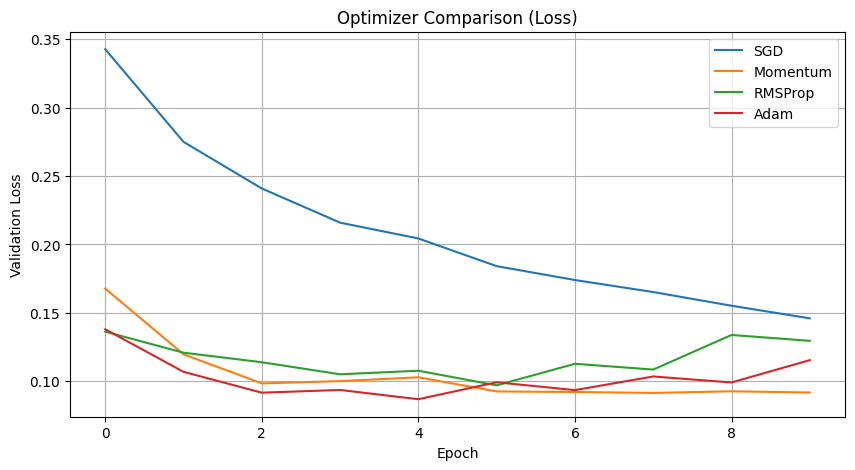

In [6]:
plt.figure(figsize=(10,5))
for name in optimizer_history:
    plt.plot(
        optimizer_history[name].history['val_loss'],
        label=name
    )
plt.title("Optimizer Comparison (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# 24BAD056-M.Karthik Saravanakumar
#PART-D

import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')
# Build the Sequential Model
model = Sequential([
    tf.keras.layers.Input(shape=(4,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])
# Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Display Model Summary
model.summary()
# Directory to Save the Model
save_dir = "/content/drive/MyDrive/24BAD056/24ADIa006L-24BAD056/EX02"
# Create Folder if it Doesn't Exist
os.makedirs(save_dir, exist_ok=True)
# Save the Model
model_path = os.path.join(save_dir, "EX02.keras")
model.save(model_path)
print("Model saved successfully!")
print("Saved at:", model_path)

Mounted at /content/drive


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

Model saved successfully!
Saved at: /content/drive/MyDrive/24BAD056/24ADIa006L-24BAD056/EX02/EX02.keras
